# Denoising Diffusion Implicit Models - DDIM

In [1]:
!pip install -Uqq git+https://github.com/1iyiwei/course22p2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 3.7 MB/s eta 0:00:00a 0:00:01


In [2]:
import pickle,gzip,math,os,time,shutil,torch,random,logging
import fastcore.all as fc,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
from collections.abc import Mapping
from pathlib import Path
from functools import partial

from fastcore.foundation import L
import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *
from miniai.accel import *
from miniai.fid import *

In [3]:
from fastprogress.fastprogress import progress_bar

In [4]:
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

mpl.rcParams['image.cmap'] = 'gray_r'
logging.disable(logging.WARNING)

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [6]:
xl,yl = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)

README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [7]:
from diffusers import UNet2DModel, DDIMPipeline, DDPMPipeline, DDIMScheduler, DDPMScheduler

## Diffusers DDPM Scheduler

In [8]:
class UNet(UNet2DModel): pass

In [18]:
try:
    model = torch.load('models/fashion_ddpm3_25.pkl', weights_only=False, map_location=device)
except Exception as e:
    print(e)
    kaggle_model_path = Path('/kaggle/input/models/liyiwei/fashion-ddpm3-25/pytorch/default/1/')
    model = torch.load(kaggle_model_path/'fashion_ddpm3_25.pkl', weights_only=False, map_location=device)

if device == torch.device("cuda"):
    model = model.cuda()

# model = torch.load('models/fashion_no-t.pkl').cuda()

[Errno 2] No such file or directory: 'models/fashion_ddpm3_25.pkl'


In [10]:
sched = DDPMScheduler(beta_end=0.01)

In [19]:
x_t = torch.randn((32,1,32,32))

if device == torch.device("cuda"):
    x_t = x_t.cuda()

In [20]:
t = 999
t_batch = torch.full((len(x_t),), t, device=x_t.device, dtype=torch.long)
with torch.no_grad(): noise = model(x_t, t_batch).sample

In [21]:
res = sched.step(noise, t, x_t)

In [22]:
res.prev_sample.shape

torch.Size([32, 1, 32, 32])

In [43]:
sz = (128,1,32,32)

In [44]:
%%time
x_t = torch.randn(sz)
if device == torch.device("cuda"):
    x_t = x_t.cuda()
preds = []

for t in progress_bar(sched.timesteps):
    with torch.no_grad(): noise = model(x_t, t).sample
    x_t = sched.step(noise, t, x_t).prev_sample
    preds.append(x_t.float().cpu())

<div><progress max="200" value="200"></progress> 100.00% [200/200 00:20&lt;00:00]</div>

CPU times: user 20.2 s, sys: 58 ms, total: 20.3 s
Wall time: 20.2 s


In [47]:
s = preds[-1].clamp(-0.5,0.5)*2

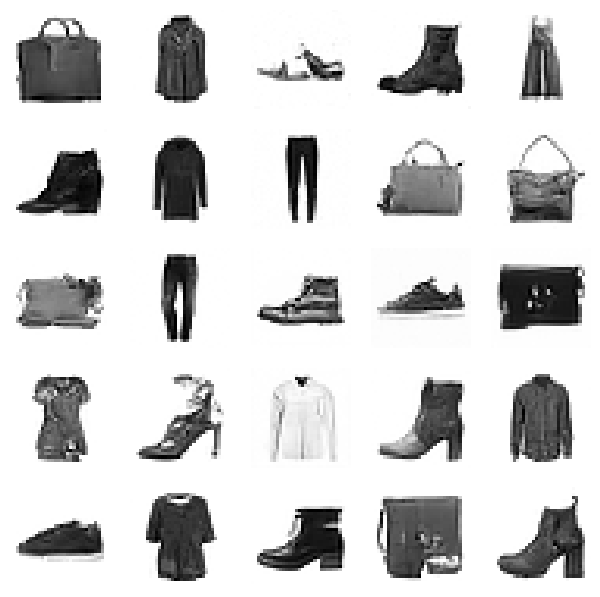

In [48]:
show_images(s[:25], imsize=1.5)

In [27]:
try:
    cmodel = torch.load('models/data_aug2.pkl', weights_only=False, map_location=device)
except Exception as e:
    print(e)
    cmodel = torch.load('/kaggle/input/models/liyiwei/data-aug2-pkl/pytorch/default/1/data_aug2.pkl', weights_only=False, map_location=device)
del(cmodel[8])
del(cmodel[7])

[Errno 2] No such file or directory: 'models/data_aug2.pkl'


In [46]:
@inplace
def transformi(b): b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2))*2-1 for o in b[xl]]

bs = 2048
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=fc.defaults.cpus)

dt = dls.train
xb,yb = next(iter(dt))

ie = ImageEval(cmodel, dls, cbs=[DeviceCB()])

In [49]:
ie.fid(s),ie.kid(s)

(172.88037109375, 0.8882923126220703)

In [30]:
ie.fid(xb),ie.kid(xb)

(1.900390625, 1.0786958932876587)

## Diffusers DDIM Scheduler

In [31]:
sched = DDIMScheduler(beta_end=0.01)
sched.set_timesteps(333)

In [33]:
def diff_sample(model, sz, sched, **kwargs):
    x_t = torch.randn(sz)
    if device == torch.device("cuda"):
        x_t = x_t.cuda()
    preds = []
    for t in progress_bar(sched.timesteps):
        with torch.no_grad(): noise = model(x_t, t).sample
        x_t = sched.step(noise, t, x_t, **kwargs).prev_sample
        preds.append(x_t.float().cpu())
    return preds

In [34]:
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1]*2).clamp(-1,1)

<div><progress max="333" value="333"></progress> 100.00% [333/333 00:34&lt;00:00]</div>

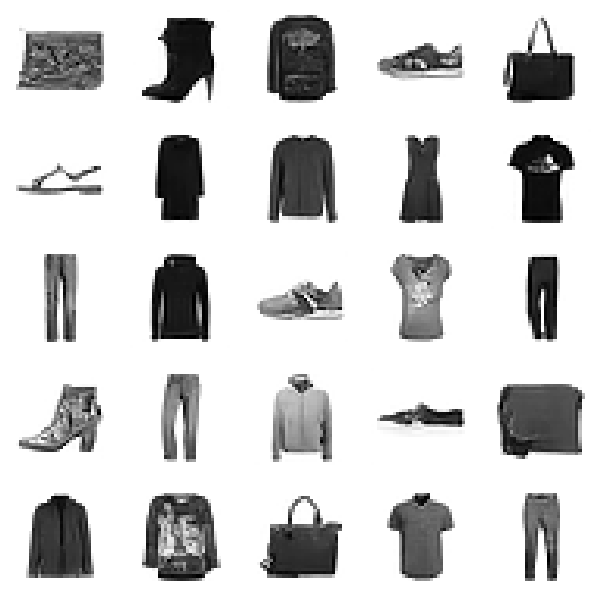

In [35]:
show_images(s[:25], imsize=1.5)

In [36]:
ie.fid(s),ie.kid(s)

(145.39599609375, 1.2067413330078125)

In [50]:
sched.set_timesteps(200)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1]*2).clamp(-1,1)
ie.fid(s),ie.kid(s)

<div><progress max="200" value="200"></progress> 100.00% [200/200 00:20&lt;00:00]</div>

(194.64697265625, 3.9219207763671875)

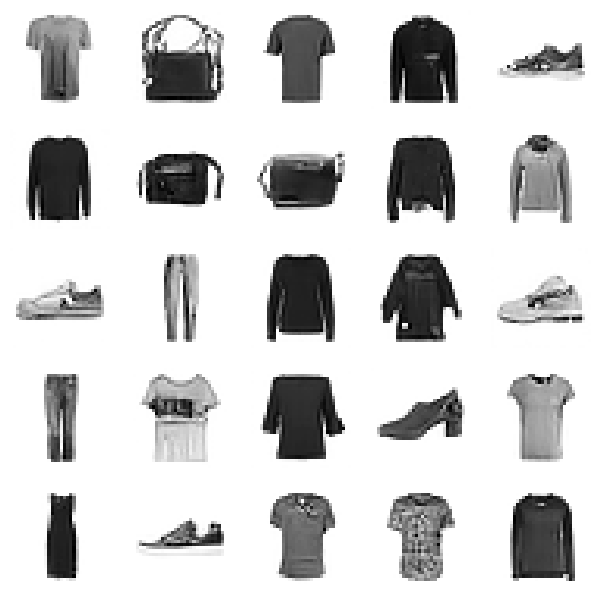

In [51]:
show_images(s[:25], imsize=1.5)

In [52]:
sched.set_timesteps(100)
preds = diff_sample(model, sz, sched, eta=1.)

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:10&lt;00:00]</div>

In [53]:
s = (preds[-1]*2).clamp(-1,1)

In [54]:
ie.fid(s),ie.kid(s)

(97.490234375, 0.013341903686523438)

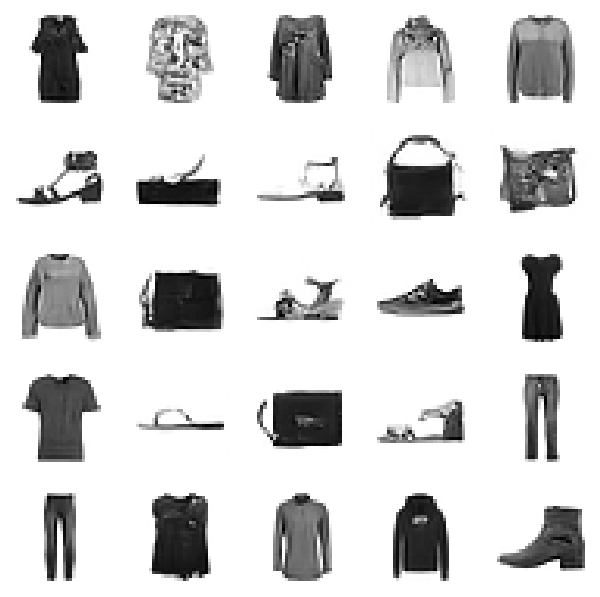

In [55]:
show_images(s[:25], imsize=1.5)

In [56]:
sched.set_timesteps(50)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1]*2).clamp(-1,1)
ie.fid(s),ie.kid(s)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:05&lt;00:00]</div>

(262.2373046875, 5.335269927978516)

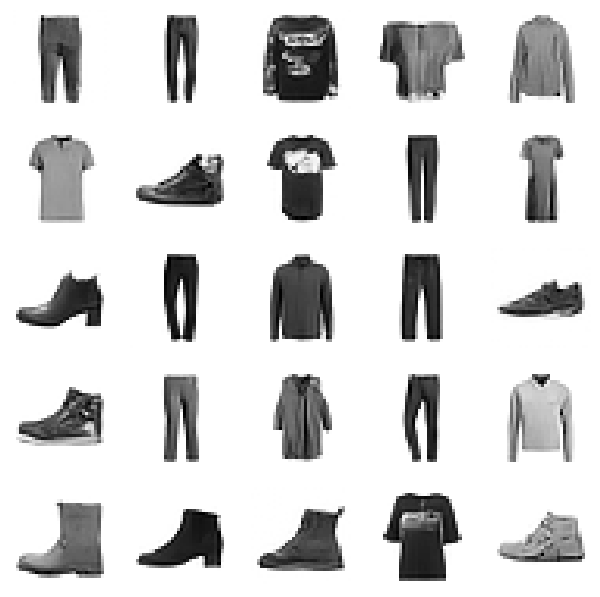

In [57]:
show_images(s[:25], imsize=1.5)

In [58]:
sched.set_timesteps(25)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1]*2).clamp(-1,1)
ie.fid(s),ie.kid(s)

<div><progress max="25" value="25"></progress> 100.00% [25/25 00:02&lt;00:00]</div>

(185.099609375, 4.178321838378906)

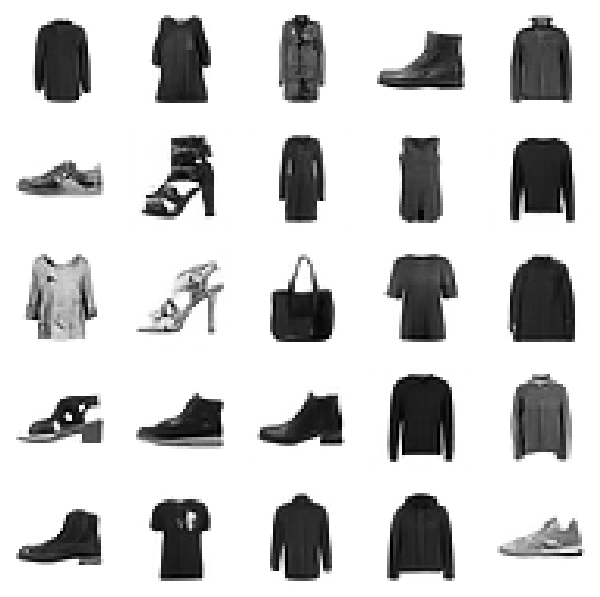

In [59]:
show_images(s[:25], imsize=1.5)

## Implementing DDIM

In [60]:
from types import SimpleNamespace

In [61]:
n_steps=1000

In [62]:
def linear_sched(betamin=0.0001,betamax=0.02,n_steps=1000):
    beta = torch.linspace(betamin, betamax, n_steps)
    return SimpleNamespace(a=1.-beta, abar=(1.-beta).cumprod(dim=0), sig=beta.sqrt())

In [63]:
sc = linear_sched(betamax=0.01, n_steps=n_steps)
abar = sc.abar

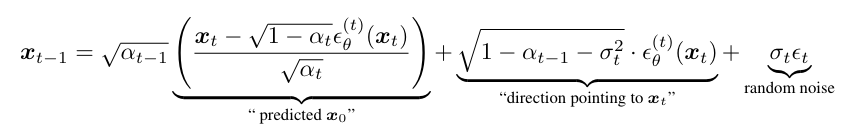

In [64]:
def ddim_step(x_t, t, noise, abar_t, abar_t1, bbar_t, bbar_t1, eta):
    vari = ((bbar_t1/bbar_t) * (1-abar_t/abar_t1))
    sig = vari.sqrt()*eta
    x_0_hat = ((x_t-bbar_t.sqrt()*noise) / abar_t.sqrt())
    x_t = abar_t1.sqrt()*x_0_hat + (bbar_t1-sig**2).sqrt()*noise
    if t>0: x_t += sig * torch.randn(x_t.shape).to(x_t)
    return x_t

In [65]:
@torch.no_grad()
def sample(f, model, sz, n_steps, skips=1, eta=1.):
    tsteps = list(reversed(range(0, n_steps, skips)))
    x_t = torch.randn(sz).to(model.device)
    preds = []
    for i,t in enumerate(progress_bar(tsteps)):
        abar_t1 = abar[tsteps[i+1]] if t > 0 else torch.tensor(1)
        noise = model(x_t,t).sample
        x_t = f(x_t, t, noise, abar[t], abar_t1, 1-abar[t], 1-abar_t1, eta)
        preds.append(x_t.float().cpu())
    return preds

In [66]:
%%time
samples = sample(ddim_step, model, sz, 1000, 10)

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:10&lt;00:00]</div>

CPU times: user 10.2 s, sys: 40.1 ms, total: 10.2 s
Wall time: 10.2 s


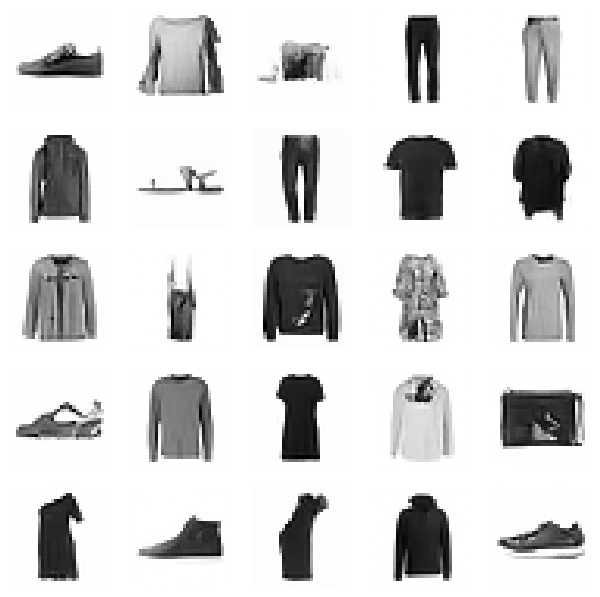

In [67]:
s = (samples[-1]*2)#.clamp(-1,1)
show_images(s[:25], imsize=1.5)

In [68]:
ie.fid(s),ie.kid(s)

(109.0390625, 1.0222911834716797)

## Triangular noise

In [69]:
def noisify(x0, ᾱ):
    device = x0.device
    n = len(x0)
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)
    t = np.random.triangular(0, 0.5, 1, (n,))*n_steps
    t = tensor(t, dtype=torch.long)
    ε = torch.randn(x0.shape, device=device)
    ᾱ_t = ᾱ[t].reshape(-1, 1, 1, 1).to(device)
    xt = ᾱ_t.sqrt()*x0 + (1-ᾱ_t).sqrt()*ε
    return (xt, t.to(device)), ε

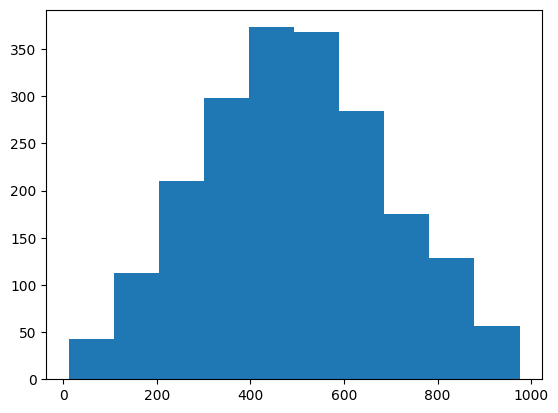

In [70]:
(xt,t),ε = noisify(xb,abar)
plt.hist(t);